In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF, NeuMF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/yelp/indexed_interactions.csv",
    sep="\t",
    header=0,
    names=[ "itemID","Category", "userID","Rating", "Gender"],
)
rating_data = rating_data_pd[["userID", "itemID","Rating"]].to_numpy()
rating_data.__len__()
rating_data_pd


,itemID,Category,userID,Rating,Gender
0,0,Food & Restaurants|Drinks & Spirits,0,5,F
1,0,Food & Restaurants|Drinks & Spirits,1,4,F
2,0,Food & Restaurants|Drinks & Spirits,2,5,F
3,0,Food & Restaurants|Drinks & Spirits,3,3,M
4,0,Food & Restaurants|Drinks & Spirits,4,3,F
...,...,...,...,...,...
97986,1271,Food & Restaurants,1060,3,F
97987,1271,Food & Restaurants,161,2,M
97988,1271,Food & Restaurants,25,3,F
97989,1271,Food & Restaurants,280,4,F


In [19]:

restaurants = pd.read_csv("./cornac/data_c/yelp/i_id_mapping.csv",sep="\t",
    header=0,
    names=[ "item_id","Category","itemID"])
restaurants=restaurants.sort_values(by="itemID")

unique_categories = [
    "Active Life & Fitness",
    "Arts & Entertainment",
    "Automotive",
    "Bars & Nightlife",
    "Coffee,Tea & Desserts",
    "Drinks & Spirits",
    "Education & Learning",
    "Event Services",
    "Family & Kids",
    "Food & Restaurants",
    "Health & Beauty",
    "Home & Garden",
    "Miscellaneous",
    "Outdoor Activities",
    "Public Services & Community",
    "Shopping & Fashion",
    "Specialty Food & Groceries",
    "Sports & Recreation",
    "Technology & Electronics",
    "Travel & Transportation",
    "Asian",
]
for c in unique_categories:
    restaurants[c] = 0
for index, row in restaurants.iterrows():
    cats = row["Category"].split("|")
    for cat in cats:
        restaurants.at[index, cat] = 1

cat = restaurants[unique_categories]
# cat[:1]
item_features_numpy = cat.to_numpy()
item_features = {
    str(item_id): {"category_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
# ids = list(range(0, 3416))

In [20]:
restaurants

,item_id,Category,itemID,Active Life & Fitness,Arts & Entertainment,Automotive,Bars & Nightlife,"Coffee,Tea & Desserts",Drinks & Spirits,Education & Learning,...,Home & Garden,Miscellaneous,Outdoor Activities,Public Services & Community,Shopping & Fashion,Specialty Food & Groceries,Sports & Recreation,Technology & Electronics,Travel & Transportation,Asian
0,34,Food & Restaurants|Drinks & Spirits,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,250,Food & Restaurants|Drinks & Spirits,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,759,Asian|Food & Restaurants,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1085,Food & Restaurants,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1122,Travel & Transportation,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,188255,Food & Restaurants,1267,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1268,188310,Food & Restaurants,1268,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1269,188449,Food & Restaurants|Bars & Nightlife,1269,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1270,188454,Food & Restaurants,1270,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:

users = pd.read_csv("./cornac/data_c/yelp/u_id_mapping.csv", sep="\t",header=0,
    names=[ "user_id","Gender","userID"])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
users = users.sort_values(by="userID")
users = users[["Gender", "userID"]]

user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
# print(item_features_numpy.shape)

(1316, 2)


In [24]:
# users
user_features_numpy[:,1]

array([   0,    1,    2, ..., 1313, 1314, 1315])

In [27]:
dataset = rating_data
unique_categories.__len__()

21

In [31]:
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,fmt="UIR"
)
models = []
model_1 = UserKNN(k=20, seed=123, verbose=True)
model_2 = ItemKNN(k=20, seed=123, verbose=True)
model_3 = MF(
            k=20,
            seed=123,
            name=f"a={0} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",batch_size=256,
            alpha=0,
            learning_rate=0.001,
            top_k=50, max_iter=20,
            # early_stopping=True
        )
model_4 = VAECF(k=32,
        autoencoder_structure=[60,40],
        act_fn="relu",
        likelihood="bern",
        n_epochs=50,
        batch_size=128,
        learning_rate=0.0005,
        alpha=0,
        top_k=50,
        beta=1,
        name=f"a={0} vae",
        seed=123,
        verbose=True,
        # early_stopping=True)
)
# model_5 = NeuMF(num_factors=8, layers=[32,16,8], act_fn="relu", num_epochs=64, batch_size=256, num_neg=3, backend="pytorch", lr=0.001, alp=0, top_k=50, name=str(0)+ "neumf")
# models.append(model_5)

models.append(model_1)
models.append(model_2)

   
cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 1315, 1315, 1315]), array([   0,    1,    2, ..., 1030,  793, 1250]), array([4., 5., 2., ..., 4., 5., 5.]))
Number of users = 1316
Number of items = 1272
Number of ratings = 67470
Max rating = 5.0
Min rating = 1.0
Global mean = 3.9
Global mean Imolicit= 1.0
::::::::
OrderedDict([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11), (12, 12), (13, 13), (14, 14), (15, 15), (16, 16), (17, 17), (18, 18), (19, 19), (20, 20), (21, 21), (22, 22), (23, 23), (24, 24), (25, 25), (26, 26), (27, 27), (28, 28), (29, 29), (30, 30), (31, 31), (32, 32), (33, 33), (34, 34), (35, 35), (36, 36), (37, 37), (38, 38), (39, 39), (40, 40), (41, 41), (42, 42), (43, 43), (44, 44), (45, 45), (46, 46), (47, 47), (48, 48), (49, 49), (50, 50), (51, 51), (52, 52), (53, 53), (54, 54), (55, 55), (56, 56), (57, 57), (58, 58), (59, 5

100%|██████████| 1316/1316 [00:00<00:00, 93979.60it/s]



[UserKNN] Evaluation started!


Ranking: 100%|██████████| 1316/1316 [00:03<00:00, 371.85it/s]



[ItemKNN] Training started!


100%|██████████| 1272/1272 [00:00<00:00, 95752.80it/s]



[ItemKNN] Evaluation started!


Ranking: 100%|██████████| 1316/1316 [00:05<00:00, 230.10it/s]


VALIDATION:
...
        |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Time (s)
------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------
UserKNN | 0.8967 | 0.5235 |      0.2834 | 0.0123 | 0.0294 |  0.0213 |       0.0074 |    0.0435 |   3.8679
ItemKNN | 0.9451 | 0.5180 |      0.3184 | 0.0137 | 0.0423 |  0.0263 |       0.0079 |    0.0508 |   6.1247

TEST:
...
        |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN | 0.9189 | 0.5258 |      0.4886 | 0.0199 | 0.0531 |  0.0312 |       0.0158 |    0.0506 |    0.0749 |   4.2986
ItemKNN | 0.9738 | 0.5180 |      0.5030 | 0.0207 | 0.0744 |  0.0344 |       0.0158 |    0.0504 |    0.0613 |   6.5756



In [37]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
item_ids.__len__()
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [39]:
reco_matrix

array([[[ 320,  775, 1213, ..., 1235,  524, 1242],
        [1213,  320,  873, ...,  403,  205,  961],
        [1213,  698,  873, ...,   11,  717,  574],
        ...,
        [1213,  320, 1217, ...,  836,  471,  356],
        [ 320, 1213,  757, ...,  999,  602,  662],
        [1213,  320,  775, ..., 1194,  605, 1013]],

       [[ 523,   78,  441, ...,  941,  100,   76],
        [ 414,  390,  546, ...,  245,  391,  859],
        [ 517,  583,  419, ...,  481, 1030,  748],
        ...,
        [1157,  208,  348, ...,  763, 1150,  394],
        [1013,  230,   48, ...,  960,  613, 1004],
        [ 331,  182,    8, ...,  889,  275,  372]]])

In [41]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 50
###intialize them
gp = GenrePrecision(users, unique_categories, top_k)
gr = GenreRecall(users, unique_categories, top_k)
gm = GenreMap(users, unique_categories, top_k)
gndcg = GenreNDCG(users, unique_categories, top_k)
gmrr = GenreMRR(users, unique_categories, top_k)

In [43]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(models)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], restaurants))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], restaurants))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], restaurants))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], restaurants))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], restaurants))




In [45]:
from operator import itemgetter

# unique_genres
# indices = [0, 1, 2, 11,14, 17]
# compare_genres = itemgetter(*indices)(unique_genres)
compare_genres = unique_categories
# indices = range(18)
list(compare_genres)

['Active Life & Fitness',
 'Arts & Entertainment',
 'Automotive',
 'Bars & Nightlife',
 'Coffee,Tea & Desserts',
 'Drinks & Spirits',
 'Education & Learning',
 'Event Services',
 'Family & Kids',
 'Food & Restaurants',
 'Health & Beauty',
 'Home & Garden',
 'Miscellaneous',
 'Outdoor Activities',
 'Public Services & Community',
 'Shopping & Fashion',
 'Specialty Food & Groceries',
 'Sports & Recreation',
 'Technology & Electronics',
 'Travel & Transportation',
 'Asian']

IndexError: list index out of range

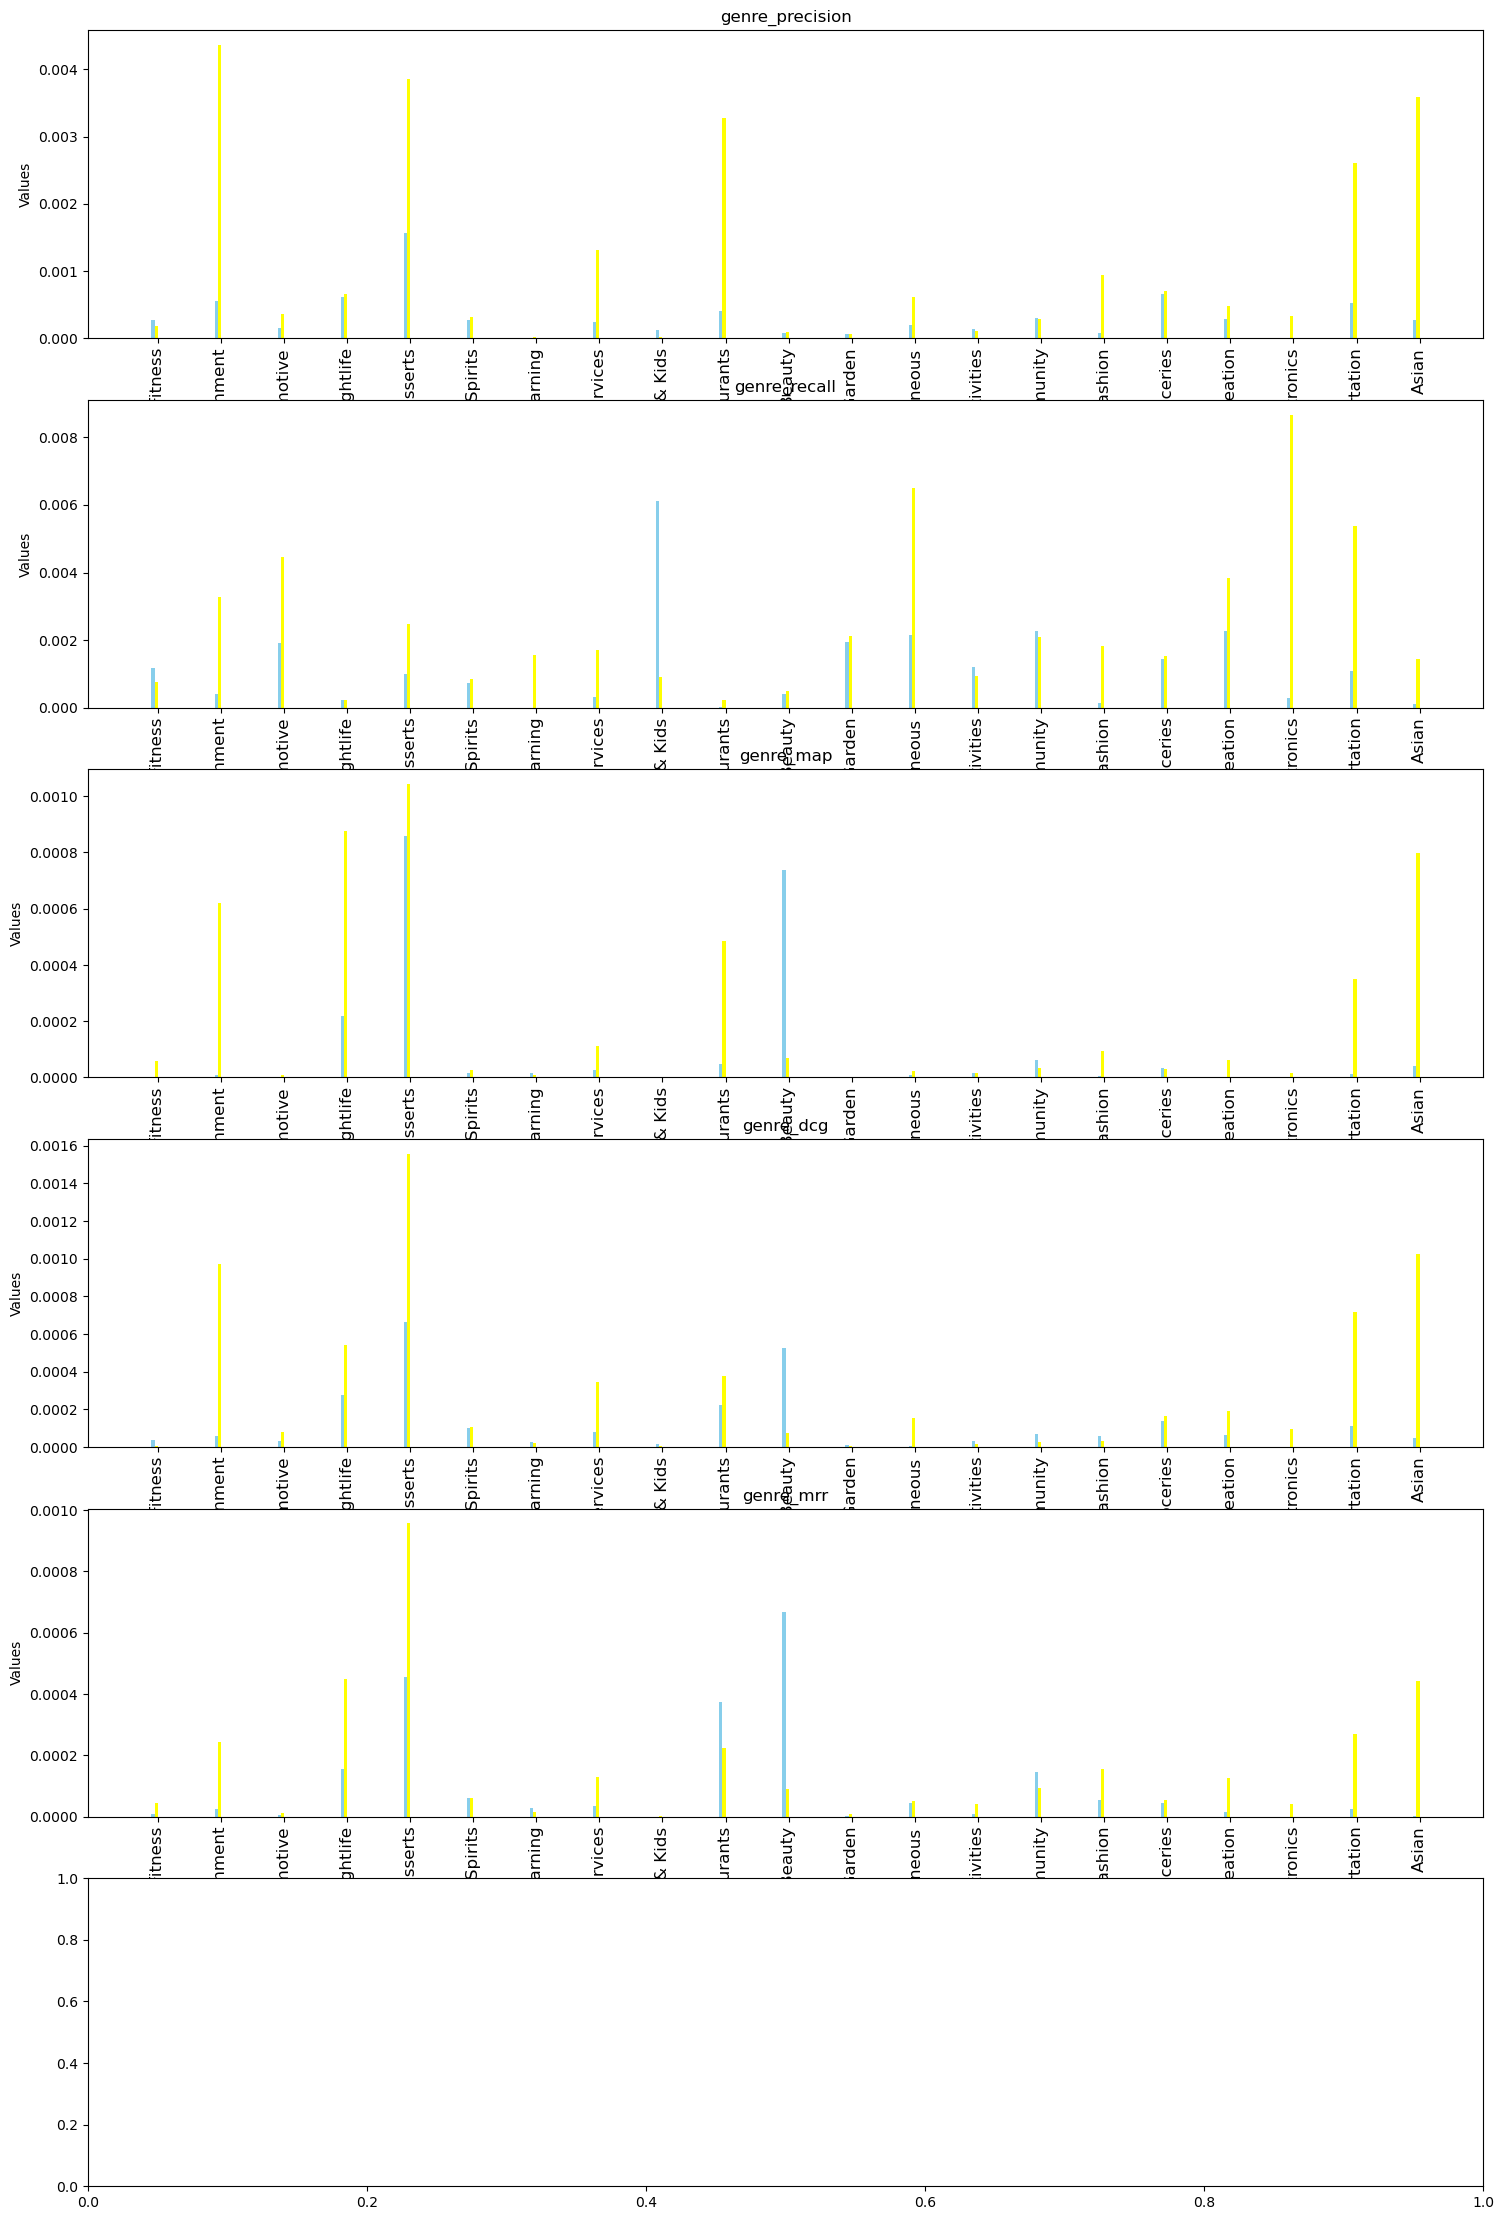

In [48]:


import matplotlib.pyplot as plt
import numpy as np


matrices = [
    model_gps[0],
    model_grs[0],
    model_gms[0],
    model_gdcgs[0],
    model_gmrrs[0],
    # model_grps[0],
]

matrices_1 = [
    model_gps[1],
    model_grs[1],
    model_gms[1],
    model_gdcgs[1],
    model_gmrrs[1],
    # model_grps[0],
]

# matrices_8 = [
#     model_gps[7][indices],
#     model_grs[7][indices],
#     model_gms[7][indices],
#     model_gdcgs[7][indices],
#     model_gmrrs[7][indices],
#     model_grps[7][indices],
# ]
# matrices_9 = [
#     model_gps[8][indices],
#     model_grs[8][indices],
#     model_gms[8][indices],
#     model_gdcgs[8][indices],
#     model_gmrrs[8][indices],
#     model_grps[8][indices],
# ]
# matrices_10 = [
#     model_gps[9][indices],
#     model_grs[9][indices],
#     model_gms[9][indices],
#     model_gdcgs[9][indices],
#     model_gmrrs[9][indices],
#     model_grps[9][indices],
# ]
# matrices_11 = [
#     model_gps[10][indices],
#     model_grs[10][indices],
#     model_gms[10][indices],
#     model_gdcgs[10][indices],
#     model_gmrrs[10][indices],
#     model_grps[10][indices],
# ]
# matrices_13 = [
#     cf_gp_10[indices],
#     cf_gr_10[indices],
#     cf_gm_10[indices],
#     cf_gndcg_10[indices],
#     cf_gmrr_10[indices],
#     model_grps[10][indices],
# ]
# matrices_13 = [
#     model_gps[12][indices],
#     model_grs[12][indices],
#     model_gms[12][indices],
#     model_gdcgs[12][indices],
#     model_gmrrs[12][indices],
#     model_grps[12][indices],
# ]



# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = compare_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 28))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, abs(matrices[i]), bar_width, color="skyblue", label="iknn"
    )
    # axs[i].bar(
    #     x - 1 * bar_width / 2, abs(matrices_2[i]), bar_width, color="pink",label=alpha_values[1]
    # )
    # axs[i].bar(
    #     x + 1 * bar_width / 2, abs(matrices_3[i]), bar_width, color="green", label=alpha_values[2]
    # )
    # axs[i].bar(
    #     x + 3 * bar_width / 2, abs(matrices_4[i]), bar_width, color="orange", label=alpha_values[3]
    # )
    # axs[i].bar(
    #     x + 5 * bar_width / 2, abs(matrices_5[i]), bar_width, color="red", label=alpha_values[4]
    # )
    axs[i].bar(
        x -1 * bar_width / 2, abs(matrices_1[i]), bar_width, color="yellow", label="uknn"
    )
    # axs[i].bar(
    #     x +1 * bar_width / 2, abs(matrices_7[i]), bar_width, color="purple", label=alpha_values[6]
    # )
    # axs[i].bar(
    #     x + 11 * bar_width / 2, matrices_8[i], bar_width, color="violet", label=alpha_values[7]
    # )
    # axs[i].bar(
    #     x + 13 * bar_width / 2, matrices_9[i], bar_width, color="black", label=alpha_values[8]
    # )
    # axs[i].bar(
    #     x + 15 * bar_width / 2,
    #     matrices_10[i],
    #     bar_width,
    #     color="chocolate",
    #    label=alpha_values[9]
    # )
    # axs[i].bar(
    #     x + 17 * bar_width / 2, matrices_11[i], bar_width, color="blue", label=alpha_values[10]
    # )
    # axs[i].bar(
    #     x + 1 * bar_width / 2, abs(matrices_12[i]), bar_width, color="gray", label="cfaira=20"
    # )
    # axs[i].bar(
    #     x + 21 * bar_width / 2, matrices_13[i], bar_width, color="violet", label="cfaira=10"
    # )
    
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")

# Adjust layout
plt.tight_layout()
plt.savefig("all_res.pdf" , format="pdf")
plt.show()

###################
# a*gender_loss + (1-a)*mseloss
# genderloss * batch_size * 25
###################